# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [12]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

file_name= "/Users/riritorti/Documents/GitHub/datascience-publicpolicy-2026/data/hw3_data/WHR26_Data_Figure_2.1.csv"
df = pd.read_csv(file_name)

df.head()
# 1. Print environment details (working directory and local folder contents)
#If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
# YOUR CODE HERE

# 2. Acquire and load your primary dataset
# YOUR CODE HERE

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

In [13]:
#dataset_source = https://www.worldhappiness.report/ed/2026/#appendices-and-data

- *Write your source here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [14]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
print("--- DATAFRAME INFO ---")
df.info()

--- DATAFRAME INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 28 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   object 
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   fl

In [15]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE
df = df.rename(columns={'Country name': 'Country',
    'Rank': 'Ranking'})
df_renamed = df.rename(columns={
    'Country name': 'Country',
    'Rank': 'Ranking'
})
df.head()

,Year,Ranking,Country,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE
df_columns = df[['Year', 'Ranking', 'Country','Life evaluation (3-year average)']]
df_columns.head()

,Year,Ranking,Country,Life evaluation (3-year average)
0,2025,1,Finland,7.764
1,2025,2,Iceland,7.540
2,2025,3,Denmark,7.539
3,2025,4,Costa Rica,7.439
4,2025,5,Sweden,7.255


In [17]:
df_countries = df[(df['Country'] == 'Finland') | (df['Country'] == 'Iceland') | (df['Country'] == 'Denmark') | (df['Country'] == 'Sweden')| (df['Country'] == 'Italy')| (df['Country'] == 'France')| (df['Country'] == 'Spain')| (df['Country'] == 'Greece')]
df_countries = df_countries[['Year', 'Ranking', 'Country','Life evaluation (3-year average)']]
df_countries.head(8)

,Year,Ranking,Country,Life evaluation (3-year average)
0,2025,1,Finland,7.764
1,2025,2,Iceland,7.540
2,2025,3,Denmark,7.539
4,2025,5,Sweden,7.255
34,2025,35,France,6.586
37,2025,38,Italy,6.574
40,2025,41,Spain,6.540
84,2025,85,Greece,5.697


In [124]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [18]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
file_name= "/Users/riritorti/Documents/GitHub/datascience-publicpolicy-2026/data/hw3_data/tipsun20_page_linear.csv"
df_unem = pd.read_csv(file_name)

df_unem.head()

,DATAFLOW,LAST UPDATE,freq,sex,age,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2009,5.7,NaN,NaN
1,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2010,5.2,NaN,NaN
2,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2011,4.9,NaN,NaN
3,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2012,5.2,NaN,NaN
4,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2013,5.7,NaN,NaN


In [19]:
df_unem = df_unem.rename(columns={'geo':'Country', 'TIME_PERIOD': 'Year', 'OBS_VALUE': 'Percentage of population in the labour force'})
df_unem_renamed = df_unem.rename(columns={
'geo':'Country','TIME_PERIOD': 'Year', 'OBS_VALUE': 'Percentage of population in the labour force'
})
df_unem.head()

,DATAFLOW,LAST UPDATE,freq,sex,age,unit,Country,Year,Percentage of population in the labour force,OBS_FLAG,CONF_STATUS
0,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2009,5.7,NaN,NaN
1,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2010,5.2,NaN,NaN
2,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2011,4.9,NaN,NaN
3,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2012,5.2,NaN,NaN
4,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Austria,2013,5.7,NaN,NaN


In [23]:
df_unem_columns = df_unem[['Year', 'Country', 'Percentage of population in the labour force']]
df_unem_columns.head()

,Year,Country,Percentage of population in the labour force
0,2009,Austria,5.7
1,2010,Austria,5.2
2,2011,Austria,4.9
3,2012,Austria,5.2
4,2013,Austria,5.7


In [24]:
df_unem_countries = df_unem[(df_unem['Country'] == 'Finland') | (df_unem['Country'] == 'Iceland') | (df_unem['Country'] == 'Denmark') | (df_unem['Country'] == 'Sweden')| (df_unem['Country'] == 'Italy')| (df_unem['Country'] == 'France')| (df_unem['Country'] == 'Spain')| (df_unem['Country'] == 'Greece')]
df_unem_countries.head(20)
df_unem_2025 = df_unem_countries[df_unem_countries['Year'] == 2025]
df_unem_2025.head ()

,DATAFLOW,LAST UPDATE,freq,sex,age,unit,Country,Year,Percentage of population in the labour force,OBS_FLAG,CONF_STATUS
118,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Denmark,2025,6.4,NaN,NaN
186,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Greece,2025,8.9,NaN,NaN
203,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Spain,2025,10.5,d,NaN
237,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,Finland,2025,9.7,NaN,NaN
260,ESTAT:TIPSUN20(1.0),29/04/26 23:00:00,Annual,Total,From 15 to 74 years,Percentage of population in the labour force,France,2025,7.7,d,NaN


In [25]:
# 1. First, create 'df_life_evaluation' from your main 'df' dataset
my_countries = ['Finland', 'Iceland', 'Denmark', 'Sweden', 'Italy', 'France', 'Spain', 'Greece']

# Filter your main dataframe for your countries and the columns you need
df_life_evaluation = df[df['Country'].isin(my_countries)]
df_life_evaluation = df_life_evaluation[['Year', 'Country', 'Ranking', 'Life evaluation (3-year average)']]

# 2. Now run your merge (with the fixed comma!)
df_merged = pd.merge(
    df_unem_countries, 
    df_life_evaluation,
    on=['Country', 'Year'], 
    how='inner'
)

# 3. Clean up and print your success message
df_merged = df_merged.dropna(subset=['Life evaluation (3-year average)'])

print(f"Success! Merged dataset contains {len(df_merged)} total records.")
print("Columns ready for plotting:", df_merged.columns.tolist())
print("-" * 60)

Success! Merged dataset contains 98 total records.
Columns ready for plotting: ['DATAFLOW', 'LAST UPDATE', 'freq', 'sex', 'age', 'unit', 'Country', 'Year', 'Percentage of population in the labour force', 'OBS_FLAG', 'CONF_STATUS', 'Ranking', 'Life evaluation (3-year average)']
------------------------------------------------------------


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [26]:

my_countries = ['Finland', 'Iceland', 'Denmark', 'Sweden', 'Italy', 'France', 'Spain', 'Greece']

df_life_evaluation = df[df['Country'].isin(my_countries)]
df_life_evaluation = df_life_evaluation[['Year', 'Country', 'Ranking', 'Life evaluation (3-year average)']]

df_merged = pd.merge(
    df_unem_countries, 
    df_life_evaluation,
    on=['Country', 'Year'], 
    how='inner'
)
df_merged = df_merged.dropna(subset=['Life evaluation (3-year average)'])

print(f"Success! Merged dataset contains {len(df_merged)} total records.")
print("Columns ready for plotting:", df_merged.columns.tolist())
print("-" * 60)

Success! Merged dataset contains 98 total records.
Columns ready for plotting: ['DATAFLOW', 'LAST UPDATE', 'freq', 'sex', 'age', 'unit', 'Country', 'Year', 'Percentage of population in the labour force', 'OBS_FLAG', 'CONF_STATUS', 'Ranking', 'Life evaluation (3-year average)']
------------------------------------------------------------


In [27]:
df_country_averages = df_merged.groupby('Country')[['Life evaluation (3-year average)', 'Percentage of population in the labour force']].mean()

# Display the summary table
print(df_country_averages)

         Life evaluation (3-year average)  \
Country                                     
Denmark                          7.600714   
Finland                          7.655286   
France                           6.612571   
Greece                           5.561000   
Italy                            6.269000   
Spain                            6.433643   
Sweden                           7.349571   

         Percentage of population in the labour force  
Country                                                
Denmark                                      5.971429  
Finland                                      8.100000  
France                                       8.721429  
Greece                                      18.050000  
Italy                                        9.642857  
Spain                                       16.892857  
Sweden                                       7.757143  


- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

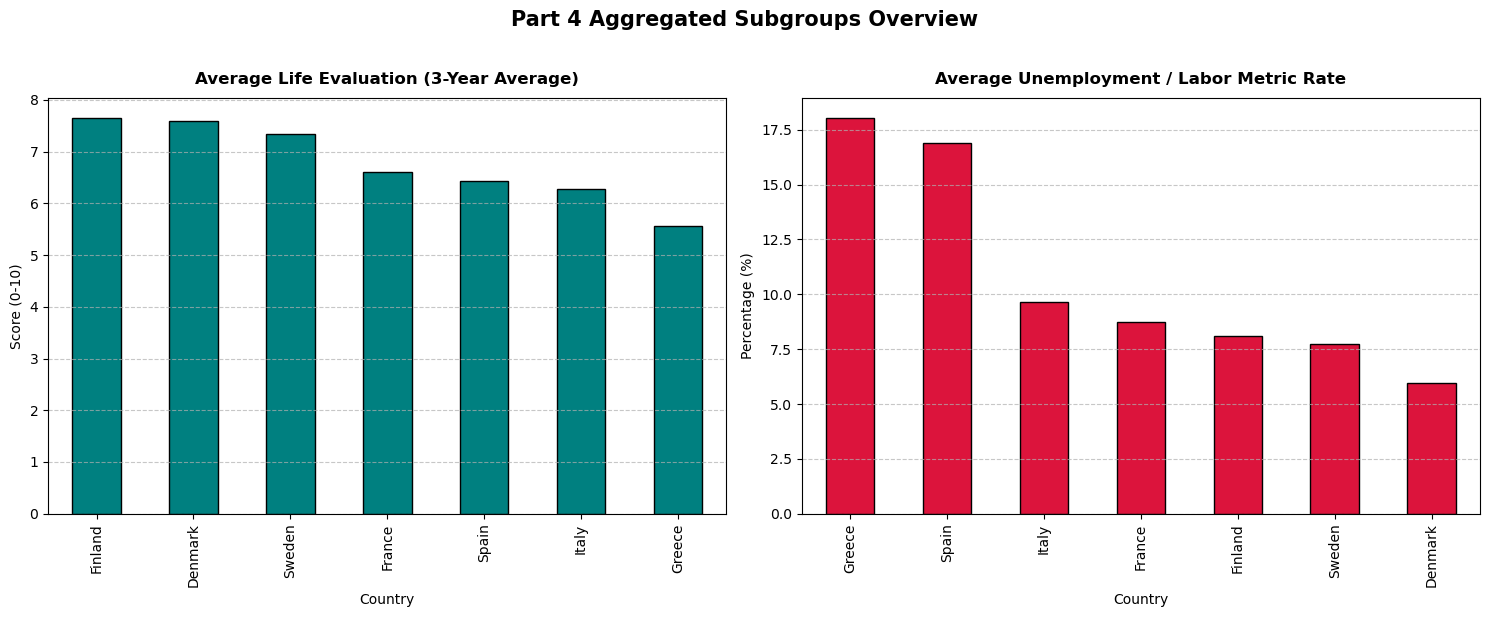

In [30]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

df_life_evaluation_sort = df_merged.groupby('Country')['Life evaluation (3-year average)'].mean().sort_values(ascending=False)
df_unem_sort = df_merged.groupby('Country')['Percentage of population in the labour force'].mean().sort_values(ascending=False)

df_life_evaluation_sort.plot(kind='bar', ax=ax1, color='teal', edgecolor='black')
ax1.set_title('Average Life Evaluation (3-Year Average)', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Score (0-10)')
ax1.set_xlabel('Country')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

df_unem_sort.plot(kind='bar', ax=ax2, color='crimson', edgecolor='black')
ax2.set_title('Average Unemployment / Labor Metric Rate', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Percentage (%)')
ax2.set_xlabel('Country')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Part 4 Aggregated Subgroups Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Unique years now in dataset: [2021 2022 2023 2024 2025]
----------------------------------------------------------------------


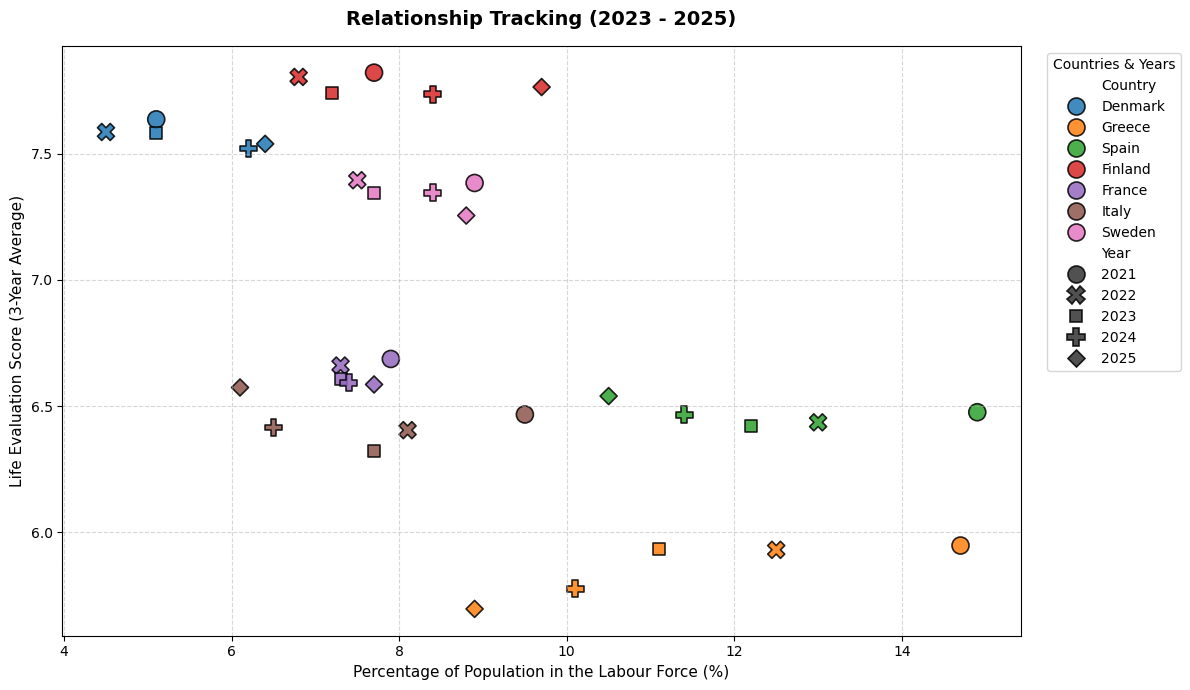

In [33]:

import matplotlib.pyplot as plt
import seaborn as sns
df_plot_years = [2021, 2022, 2023, 2024, 2025]
df_plot_years = df_merged[df_merged['Year'].isin(plot_years)]

print(f"Unique years now in dataset: {df_plot_years['Year'].unique()}")
print("-" * 70)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='Percentage of population in the labour force',
    y='Life evaluation (3-year average)',
    hue='Country',     
    style='Year',    
    data=df_plot_years,
    s=150,              
    alpha=0.85,
    edgecolor='black',
    linewidth=1.2
)
plt.title('Relationship Tracking (2023 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of Population in the Labour Force (%)', fontsize=11)
plt.ylabel('Life Evaluation Score (3-Year Average)', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Countries & Years")

plt.tight_layout()
plt.show()

                                   OLS Regression Results                                   
Dep. Variable:     Life evaluation (3-year average)   R-squared:                       0.323
Model:                                          OLS   Adj. R-squared:                  0.303
Method:                               Least Squares   F-statistic:                     15.77
Date:                              Mon, 08 Jun 2026   Prob (F-statistic):           0.000365
Time:                                      17:05:11   Log-Likelihood:                -27.969
No. Observations:                                35   AIC:                             59.94
Df Residuals:                                    33   BIC:                             63.05
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                                                   coef    std err    

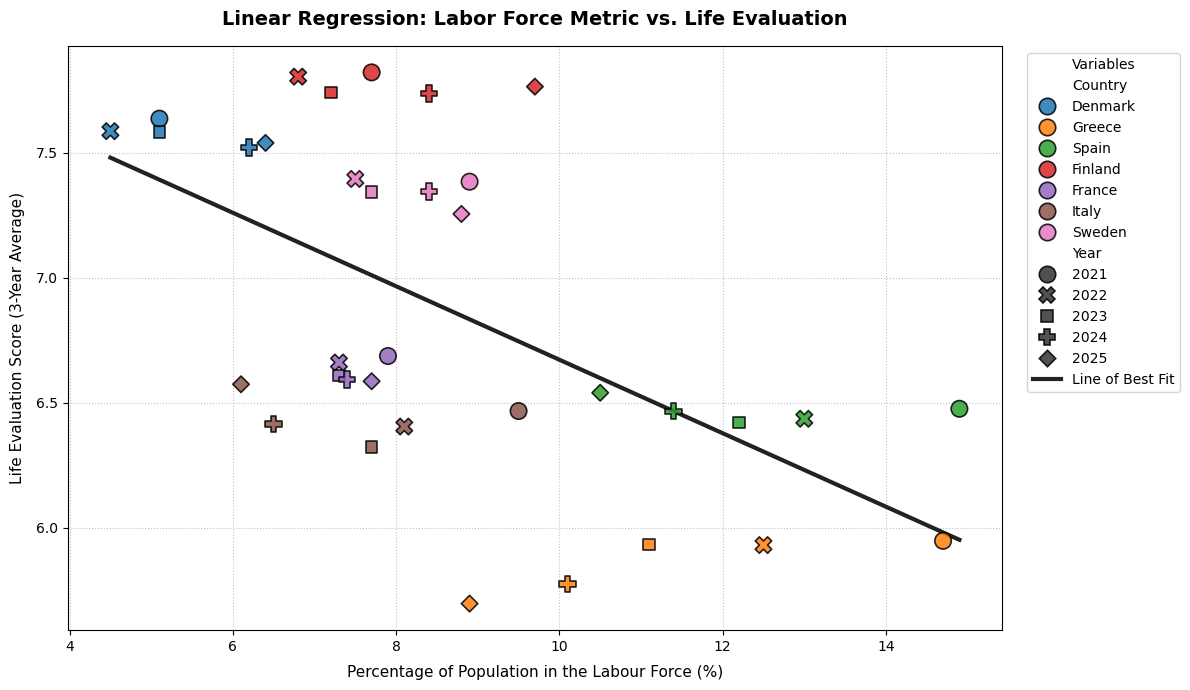

In [37]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

X = df_plot_years['Percentage of population in the labour force']
y = df_plot_years['Life evaluation (3-year average)']

X_with_constant = sm.add_constant(X)

model = sm.OLS(y, X_with_constant).fit()

print(model.summary())
print("-" * 80)
plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='Percentage of population in the labour force',
    y='Life evaluation (3-year average)',
    hue='Country',
    style='Year',
    data=df_plot_years,
    s=140,
    alpha=0.85,
    edgecolor='black',
    linewidth=1.2,
    zorder=3 
)

X_range = np.linspace(X.min(), X.max(), 100)
X_range_with_constant = sm.add_constant(X_range)

y_predictions = model.predict(X_range_with_constant)

plt.plot(
    X_range, 
    y_predictions, 
    color='#222222',  
    linestyle='-', 
    linewidth=3, 
    label='Line of Best Fit',
    zorder=2       
)
plt.title('Linear Regression: Labor Force Metric vs. Life Evaluation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of Population in the Labour Force (%)', fontsize=11, labelpad=8)
plt.ylabel('Life Evaluation Score (3-Year Average)', fontsize=11, labelpad=8)

plt.grid(True, linestyle=':', alpha=0.6, color='#999999', zorder=1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Variables")

plt.tight_layout()
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.